In [1]:
#!pip install matplotlib

# Validation: do repeaters concentrate at the top of the anomaly rankings?

The three methods in `02_methods` each rank all 558 sub-bursts by how anomalous
they are. This notebook asks whether those rankings carry real signal, using known
repeaters as a yardstick: repeaters are a morphologically distinct population
(Pleunis et al. 2021), so if a method is picking up genuine morphological oddness,
repeaters should be over-represented near the top of its ranking.

**The independence problem.** A repeater source emits many sub-bursts, each a
separate row, and those rows are correlated. A naive test that treats them as
independent observations reports p-values that are too small. We handle this two
ways and report both:

- **Per-sub-burst, with a source-level permutation test** (headline). Keeps every
  row, but builds the null distribution by shuffling the repeater label at the
  *source* level, so a source's sub-bursts always share a label. This respects the
  correlation instead of pretending it away.
- **Aggregated to one row per source** (cross-check). Collapses each source to its
  single most anomalous sub-burst. If this agrees with the per-sub-burst result, the
  signal is broad across sources; if it is much weaker, a few prolific repeaters were
  propping up the headline.

**Two test statistics**, both run through the same permutation:

- **AUC (Mann-Whitney U):** across the whole ranking, how often does a random
  repeater outrank a random one-off? 0.5 = no signal.
- **Top-K enrichment (Fisher-style):** is the extreme tail (top 5/10/20%) specifically
  over-represented by repeaters?

Three methods means three tests per statistic, so p-values are Bonferroni-corrected
(multiplied by 3).

In [2]:
# Load the per-burst method scores written by 02_methods. This is the only input.
import sys
from pathlib import Path

PROJECT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

scores_path = PROJECT / 'data' / 'processed' / 'phase_1' / 'catalog1_method_scores.csv'
scores = pd.read_csv(scores_path)

# is_repeater round-trips through CSV as the string 'True'/'False'; cast back to bool.
scores['is_repeater'] = scores['is_repeater'].astype(str).str.lower() == 'true'

print(f'Loaded {len(scores)} bursts')
print(f'  repeaters: {int(scores["is_repeater"].sum())}')
print(f'  one-offs:  {int((~scores["is_repeater"]).sum())}')
print(f'  columns:   {list(scores.columns)}')
print()
print(scores.head().to_string(index=False))

Loaded 558 bursts
  repeaters: 90
  one-offs:  468
  columns:   ['Name', 'RpName', 'is_repeater', 'maha_score', 'lof_median_rank', 'eif_score']

        Name RpName  is_repeater  maha_score  lof_median_rank  eif_score
FRB20180904A  -9999        False   13.766915            424.0   0.392604
FRB20180906A  -9999        False  116.336425            294.0   0.427485
FRB20180906B  -9999        False   12.831432             35.0   0.479962
FRB20180907D  -9999        False   66.543835            149.0   0.446207
FRB20180907A  -9999        False   11.210035            227.0   0.400399


In [3]:
# Group sub-bursts into sources.
#
# Every test below assumes each row is an independent observation. That is false as
# it stands: a repeater source emits many sub-bursts, each its own row, and those rows
# are correlated (same source, same physics). We need a source id to (a) aggregate a
# source's sub-bursts to one row, and (b) shuffle labels at the source level in the
# permutation test.
#
# The trap: for one-offs, RpName is the sentinel -9999, shared by all 468 of them. If
# we grouped by RpName alone, every one-off would collapse into a single fake 'source'.
# So: repeaters group by RpName; each one-off is its own source, keyed by its Name.

scores['source_id'] = np.where(scores['is_repeater'], scores['RpName'], scores['Name'])

n_sources = scores['source_id'].nunique()
n_rep_sources = scores.loc[scores['is_repeater'], 'source_id'].nunique()
n_oneoff_sources = scores.loc[~scores['is_repeater'], 'source_id'].nunique()

print(f'{len(scores)} sub-bursts collapse to {n_sources} sources')
print(f'  repeater sources: {n_rep_sources}')
print(f'  one-off sources:  {n_oneoff_sources}')
print()
# The repeater sources with the most sub-bursts: these are the ones whose duplication
# would most distort a naive per-sub-burst test, and the reason we shuffle at the
# source level rather than the row level.
rep_counts = (scores[scores['is_repeater']]
              .groupby('source_id').size()
              .sort_values(ascending=False))
print('Repeater sources by sub-burst count (top 10):')
print(rep_counts.head(10).to_string())

558 sub-bursts collapse to 456 sources
  repeater sources: 18
  one-off sources:  438

Repeater sources by sub-burst count (top 10):
source_id
FRB20180916B    33
FRB20180814A    16
FRB20190208A     5
FRB20181128A     4
FRB20121102A     3
FRB20190303A     3
FRB20190222A     3
FRB20181119A     3
FRB20190212A     3
FRB20190209A     2


In [4]:
# Orient every method so HIGHER = more anomalous, for all three.
#
# maha_score and eif_score already follow that convention. lof_median_rank does NOT:
# it is a rank where LOWER means more outlying. We flip it by negating, so a small rank
# (very outlying) becomes a large oriented score. The actual values are arbitrary; only
# the ORDER matters for these rank-based tests, and negation reverses the order
# correctly without distorting anything.

oriented = pd.DataFrame({
    'maha': scores['maha_score'],
    'lof':  -scores['lof_median_rank'],   # flip: lower rank (more outlying) -> higher score
    'eif':  scores['eif_score'],
}, index=scores.index)
methods = ['maha', 'lof', 'eif']

# Self-check: the single most anomalous burst by each oriented score should be
# FRB20190429B, which topped all three methods in 02_methods. If a flip is wrong,
# this line will show the wrong burst (or an inlier) and we catch it immediately.
for m in methods:
    top = scores.loc[oriented[m].idxmax(), 'Name']
    print(f'{m}: most anomalous burst = {top}')

maha: most anomalous burst = FRB20190429B
lof: most anomalous burst = FRB20190429B
eif: most anomalous burst = FRB20190429B


In [5]:
# The statistical engine: two statistics, one source-level permutation null.
#
# KEY INSIGHT that makes this both cheap and correct: a permutation test here shuffles
# only the LABELS, never the scores. The ranking of bursts is fixed; all that changes
# from shuffle to shuffle is which bursts are *called* repeaters. So we precompute the
# ranks once and just re-select under each random assignment.

def auc_from_mask(ranks, rep_mask):
    # AUC = P(a random repeater outranks a random one-off), via the Mann-Whitney rank
    # identity. 0.5 = no signal; 1.0 = every repeater ranked above every one-off.
    n_rep = int(rep_mask.sum())
    n_one = len(ranks) - n_rep
    rep_rank_sum = ranks[rep_mask].sum()
    return (rep_rank_sum - n_rep * (n_rep + 1) / 2) / (n_rep * n_one)

def topk_counts(order_desc, rep_mask, ks):
    # How many of the K most anomalous bursts are repeaters. The top-K SET of bursts is
    # fixed (scores never move); only their labels change under the shuffle.
    return {k: int(rep_mask[order_desc[:k]].sum()) for k in ks}

def source_permutation(score, src_codes, true_rep_mask, ks, n_perm=10000, seed=0):
    rng = np.random.default_rng(seed)
    n_sources = int(src_codes.max()) + 1

    # Labels are constant within a source, so the repeater sources are just the distinct
    # source codes that carry a True label. We relabel this many sources each shuffle.
    n_rep_sources = len(np.unique(src_codes[true_rep_mask]))

    ranks = pd.Series(score).rank().to_numpy()   # average ranks, ties shared fairly
    order_desc = np.argsort(-score)              # row positions, most anomalous first

    # observed statistics, on the REAL labels
    obs_auc = auc_from_mask(ranks, true_rep_mask)
    obs_topk = topk_counts(order_desc, true_rep_mask, ks)

    # null: repeatedly relabel n_rep_sources sources at random, propagate to their rows
    null_auc = np.empty(n_perm)
    null_topk = {k: np.empty(n_perm, dtype=int) for k in ks}
    for i in range(n_perm):
        chosen = rng.choice(n_sources, size=n_rep_sources, replace=False)
        is_rep_source = np.zeros(n_sources, dtype=bool)
        is_rep_source[chosen] = True
        perm_mask = is_rep_source[src_codes]     # each row inherits its source's label
        null_auc[i] = auc_from_mask(ranks, perm_mask)
        tk = topk_counts(order_desc, perm_mask, ks)
        for k in ks:
            null_topk[k][i] = tk[k]

    # one-sided p-values: fraction of shuffles AT OR BEYOND the observed (we expect
    # repeaters to score higher). The +1 counts the real arrangement itself, so p can
    # never come out as an impossible exact zero.
    p_auc = (1 + int(np.sum(null_auc >= obs_auc))) / (n_perm + 1)
    p_topk = {k: (1 + int(np.sum(null_topk[k] >= obs_topk[k]))) / (n_perm + 1) for k in ks}

    return {'obs_auc': obs_auc, 'p_auc': p_auc, 'null_auc': null_auc,
            'obs_topk': obs_topk, 'p_topk': p_topk, 'null_topk': null_topk,
            'n_rep_sources': n_rep_sources}

# Smoke test on ONE method (Mahalanobis, per-sub-burst) to confirm the engine runs and
# gives sane numbers before we wire up all three. ~a few seconds for 10,000 shuffles.
_src_codes = pd.factorize(scores['source_id'])[0]
_rep_mask = scores['is_repeater'].to_numpy()
_demo = source_permutation(oriented['maha'].to_numpy(), _src_codes, _rep_mask,
                           ks=[28, 56, 112], n_perm=10000, seed=0)
n_tot = int(_src_codes.max()) + 1
print('[smoke test] Mahalanobis, per-sub-burst, 10,000 source-level shuffles:')
print(f'  observed AUC        = {_demo["obs_auc"]:.3f}   (0.5 = no signal)')
print(f'  permutation p-value = {_demo["p_auc"]:.4f}')
print(f'  top 10% (56 bursts) = {_demo["obs_topk"][56]} repeaters,  p = {_demo["p_topk"][56]:.4f}')
print(f'  ({_demo["n_rep_sources"]} repeater sources shuffled among {n_tot} total)')

[smoke test] Mahalanobis, per-sub-burst, 10,000 source-level shuffles:
  observed AUC        = 0.891   (0.5 = no signal)
  permutation p-value = 0.0001
  top 10% (56 bursts) = 36 repeaters,  p = 0.0001
  (18 repeater sources shuffled among 456 total)


In [ ]:
# Headline test: all three methods, per-sub-burst, source-level permutation.
# Three methods means three tests, so we Bonferroni-correct the AUC p-values
# (multiply by 3, capped at 1) to control the chance of a fluke among them.

N = len(scores)
KS = [int(round(f * N)) for f in (0.05, 0.10, 0.20)]   # top 5%, 10%, 20% = [28, 56, 112]
src_codes = pd.factorize(scores['source_id'])[0]
rep_mask = scores['is_repeater'].to_numpy()
baseline = rep_mask.mean()                              # fraction of all rows that are repeaters

results_psb = {m: source_permutation(oriented[m].to_numpy(), src_codes, rep_mask,
                                      ks=KS, n_perm=10000, seed=0) for m in methods}

# Whole-ranking signal (AUC / Mann-Whitney). 'sigma' = (AUC - 0.5) / SD_null is how many
# standard deviations the observed AUC sits above the permutation null mean, the SD taken
# straight from the null (null_auc.std(), no independence assumption). It is the magnitude
# the floored p-value hides: two methods can share p = 0.0001 yet sit very different
# distances out.
auc_tbl = pd.DataFrame([{
    'method': m,
    'AUC': round(results_psb[m]['obs_auc'], 3),
    'sigma': round((results_psb[m]['obs_auc'] - 0.5) / results_psb[m]['null_auc'].std(), 1),
    'p': results_psb[m]['p_auc'],
    'p_Bonferroni': min(1.0, results_psb[m]['p_auc'] * len(methods)),
} for m in methods])

# Tail enrichment (Fisher-style: repeaters in the top K vs expected by chance)
enr_tbl = pd.DataFrame([{
    'method': m, 'K (tier)': k,
    'repeaters': results_psb[m]['obs_topk'][k],
    'expected': round(baseline * k, 1),
    'p': results_psb[m]['p_topk'][k],
} for m in methods for k in KS])

print(f'PER-SUB-BURST test: N={N} rows, {int(rep_mask.sum())} repeater rows, baseline rep fraction {baseline:.3f}.')
print(f'Top-K tiers: {KS[0]} (5%), {KS[1]} (10%), {KS[2]} (20%).')
print()
print('Whole-ranking signal (AUC, Mann-Whitney):')
print(auc_tbl.to_string(index=False))
print()
print('Tail enrichment (repeaters in top K vs expected by chance):')
print(enr_tbl.to_string(index=False))

In [ ]:
# Aggregated cross-check: collapse each source to ONE row, its most anomalous sub-burst,
# and rerun everything. Now FRB20180916B counts once instead of 33 times. This is the
# arbiter: if the signal survives here, it is broad across the 18 repeater SOURCES; if
# it collapses, a few prolific repeaters were inflating the per-sub-burst numbers.

agg = pd.DataFrame({'source_id': scores['source_id'], 'is_repeater': scores['is_repeater'].values})
for m in methods:
    agg[m] = oriented[m].values
# one row per source: take its MOST anomalous sub-burst (max oriented score) per method
agg = agg.groupby('source_id').agg(
    is_repeater=('is_repeater', 'first'),
    maha=('maha', 'max'), lof=('lof', 'max'), eif=('eif', 'max'),
).reset_index()

M = len(agg)
KS_agg = [int(round(f * M)) for f in (0.05, 0.10, 0.20)]   # top 5/10/20% of sources
agg_rep_mask = agg['is_repeater'].to_numpy()
agg_src_codes = np.arange(M)                                # each source is its own 'source'
agg_baseline = agg_rep_mask.mean()

results_agg = {m: source_permutation(agg[m].to_numpy(), agg_src_codes, agg_rep_mask,
                                     ks=KS_agg, n_perm=10000, seed=0) for m in methods}

# 'sigma' = (AUC - 0.5) / SD_null, the observed AUC in standard deviations above the
# null mean. Independence holds here (one row per source), so this matches the analytic
# formula sqrt((n_rep + n_one + 1) / (12 * n_rep * n_one)); we still read it off the
# permutation null for consistency with the per-sub-burst table.
auc_tbl_agg = pd.DataFrame([{
    'method': m,
    'AUC': round(results_agg[m]['obs_auc'], 3),
    'sigma': round((results_agg[m]['obs_auc'] - 0.5) / results_agg[m]['null_auc'].std(), 1),
    'p': results_agg[m]['p_auc'],
    'p_Bonferroni': min(1.0, results_agg[m]['p_auc'] * len(methods)),
} for m in methods])

enr_tbl_agg = pd.DataFrame([{
    'method': m, 'K (tier)': k,
    'repeaters': results_agg[m]['obs_topk'][k],
    'expected': round(agg_baseline * k, 1),
    'p': results_agg[m]['p_topk'][k],
} for m in methods for k in KS_agg])

print(f'AGGREGATED test: M={M} sources, {int(agg_rep_mask.sum())} repeater sources, baseline {agg_baseline:.3f}.')
print(f'Top-K tiers: {KS_agg[0]} (5%), {KS_agg[1]} (10%), {KS_agg[2]} (20%).')
print()
print('Whole-ranking signal (AUC, Mann-Whitney):')
print(auc_tbl_agg.to_string(index=False))
print()
print('Tail enrichment (repeater sources in top K vs expected by chance):')
print(enr_tbl_agg.to_string(index=False))
print()
# The headline comparison: how much does each method's AUC shrink when every source
# counts once? A big drop means prolific repeaters were carrying the per-sub-burst result.
cmp = pd.DataFrame([{
    'method': m,
    'AUC_per_sub_burst': round(results_psb[m]['obs_auc'], 3),
    'AUC_aggregated': round(results_agg[m]['obs_auc'], 3),
} for m in methods])
print('AUC per-sub-burst vs aggregated (big gap = a few sources were inflating it):')
print(cmp.to_string(index=False))

In [8]:
# Candidate list for Phase 2. The validation shows the methods track genuine morphology,
# so their top-ranked bursts are worth a closer look on the waterfalls. The most
# interesting are the NON-repeaters near the top: repeaters are already known to be odd,
# so a one-off ranking as highly as them is a genuine anomaly, not an explained one.

ranked = scores[['Name', 'is_repeater', 'source_id']].copy()
for m in methods:
    ranked[f'{m}_rank'] = (-oriented[m]).rank(method='min').astype(int)   # 1 = most anomalous
ranked['mean_rank'] = ranked[[f'{m}_rank' for m in methods]].mean(axis=1)
ranked = ranked.sort_values('mean_rank')

rank_cols = ['maha_rank', 'lof_rank', 'eif_rank']

print('Top 20 bursts by mean rank across the three methods:')
print(ranked.head(20)[['Name', 'is_repeater', *rank_cols, 'mean_rank']].to_string(index=False))

# All-methods-agree set: in the top 10% (56) of EVERY method independently. These are
# the most robust anomalies, flagged by distance, density AND isolation alike.
TOP = 56
agree = ranked[(ranked[rank_cols] <= TOP).all(axis=1)]
print(f'\nIn the top {TOP} (top 10%) of ALL THREE methods: {len(agree)} bursts')
print(agree[['Name', 'is_repeater', *rank_cols]].to_string(index=False))

# The Phase 2 shortlist: highest-ranked NON-repeaters (the genuine, unexplained anomalies).
nonrep = ranked[~ranked['is_repeater']].head(10)
print('\nTop 10 NON-repeater anomalies (the Phase 2 shortlist):')
print(nonrep[['Name', *rank_cols, 'mean_rank']].to_string(index=False))

Top 20 bursts by mean rank across the three methods:
        Name  is_repeater  maha_rank  lof_rank  eif_rank  mean_rank
FRB20190429B        False          1         1         1   1.000000
FRB20181228B        False          4         2         3   3.000000
FRB20190625E         True          2         3         5   3.333333
FRB20181028A         True          3         4         4   3.666667
FRB20190626A         True          8        13        12  11.000000
FRB20190519J        False          5        12        29  15.333333
FRB20181222A         True         29        17        10  18.666667
FRB20181028A         True          9        34        24  22.333333
FRB20181222A         True         30        27        16  24.333333
FRB20190625E         True          6        40        31  25.666667
FRB20181028A         True         14        49        22  28.333333
FRB20180917A         True         63        19        11  31.000000
FRB20181028A         True         25        52        17  31.33

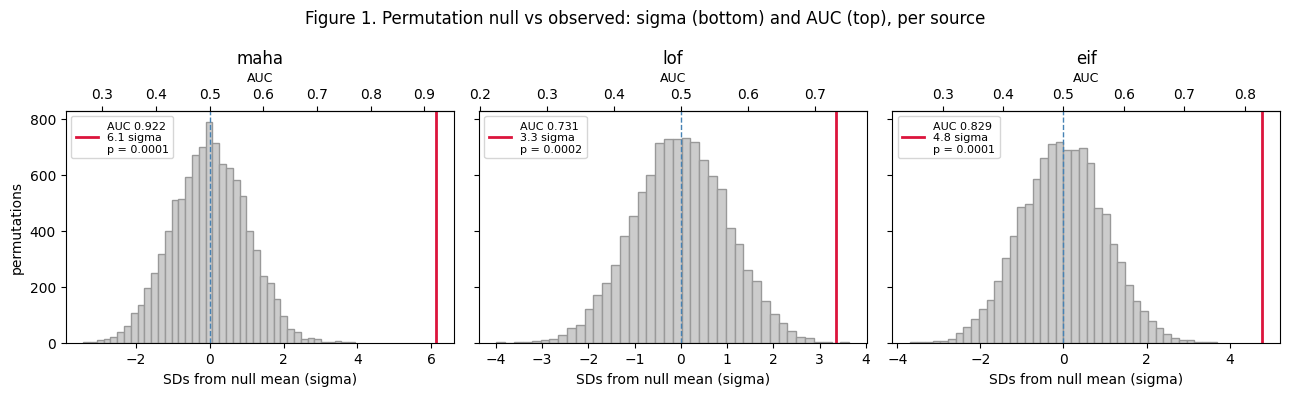

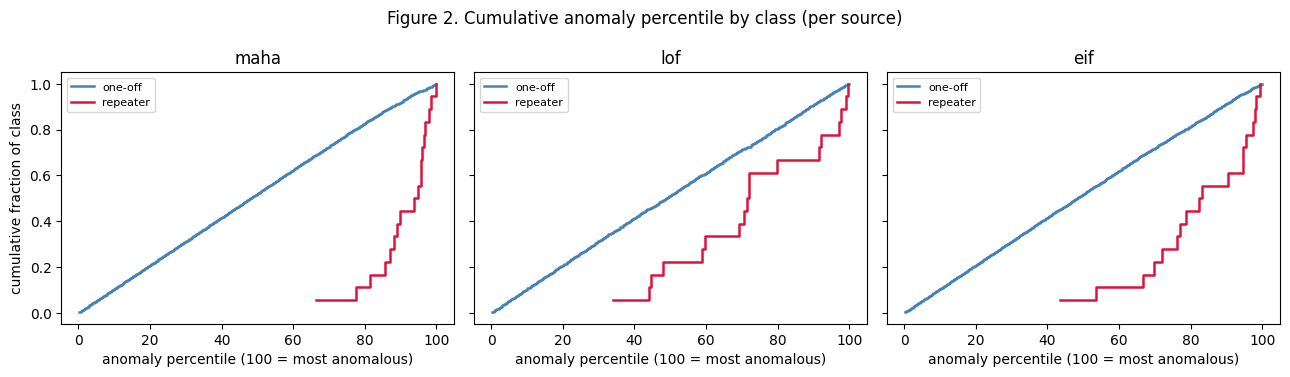

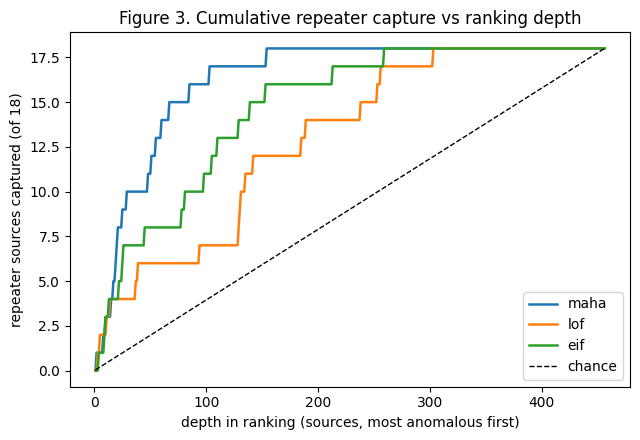

In [14]:
# Three figures, one per claim, all on the aggregated (per-source) data, the headline result.
FIGDIR = PROJECT / 'reports' / 'Phase 1' / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

# --- Figure 1: permutation null vs observed, dual scale (sigma on bottom, AUC on top) ---
# Grey = the 10,000 shuffled AUCs (what AUC looks like if repeater-ness were random),
# standardised to SIGMA = (AUC - 0.5) / SD_null. Standardising makes the null unit-width
# in every panel, so the three methods are directly comparable and you can read the
# observed result in 'SDs above chance' straight off the bottom axis. The top axis carries
# the same thing back in native AUC units. Red = observed; blue dashed = 0 sigma (AUC 0.5,
# no signal). SD_null is just null_auc.std(), the null width with no independence assumption.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharey=True)
for ax, m in zip(axes, methods):
    r = results_agg[m]
    sd = r['null_auc'].std()
    null_sigma = (r['null_auc'] - 0.5) / sd
    obs_sigma = (r['obs_auc'] - 0.5) / sd
    ax.hist(null_sigma, bins=40, color='0.8', edgecolor='0.6')
    ax.axvline(0, color='steelblue', ls='--', lw=1)
    ax.axvline(obs_sigma, color='crimson', lw=2,
               label=f"AUC {r['obs_auc']:.3f}\n{obs_sigma:.1f} sigma\np = {r['p_auc']:.4f}")
    ax.set_title(m); ax.set_xlabel('SDs from null mean (sigma)')
    ax.legend(fontsize=8, loc='upper left')
    # top axis back in native AUC units: AUC = 0.5 + sigma * SD (sd bound per panel)
    secax = ax.secondary_xaxis('top', functions=(lambda s, sd=sd: 0.5 + s * sd,
                                                 lambda a, sd=sd: (a - 0.5) / sd))
    secax.set_xlabel('AUC', fontsize=9)
axes[0].set_ylabel('permutations')
fig.suptitle('Figure 1. Permutation null vs observed: sigma (bottom) and AUC (top), per source')
fig.tight_layout()
fig.savefig(FIGDIR / 'fig1_null_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 2: cumulative distribution of anomaly percentile by class ---
# Histograms were unreadable: maha's single huge outlier owned the x-axis, and 18
# repeaters make a spiky histogram. Fix: percentile rank (0-100) puts all three methods
# on a common axis and tames the outlier; an ECDF (cumulative curve) is smooth even for
# 18 points. The horizontal gap between the curves IS the AUC effect made visual: the
# repeater curve sitting low-and-right means repeaters hold the higher percentiles.
def ecdf(v):
    v = np.sort(v)
    return v, np.arange(1, len(v) + 1) / len(v)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, m in zip(axes, methods):
    pct = pd.Series(agg[m]).rank(pct=True).to_numpy() * 100   # 0-100, 100 = most anomalous
    for mask, color, label in [(~agg_rep_mask, 'steelblue', 'one-off'),
                               (agg_rep_mask, 'crimson', 'repeater')]:
        xv, yv = ecdf(pct[mask])
        ax.step(xv, yv, where='post', color=color, lw=1.8, label=label)
    ax.set_title(m); ax.set_xlabel('anomaly percentile (100 = most anomalous)')
    ax.legend(fontsize=8, loc='upper left')
axes[0].set_ylabel('cumulative fraction of class')
fig.suptitle('Figure 2. Cumulative anomaly percentile by class (per source)')
fig.tight_layout()
fig.savefig(FIGDIR / 'fig2_score_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 3: cumulative repeater capture (what the top-K / tail test measures) ---
# Walk down each method's ranking, most anomalous first; plot how many of the 18 repeater
# sources have been captured by each depth. Dashed = chance. Curves bowing above chance
# are tail enrichment; the steeper the early climb, the better the method at the very top.
fig, ax = plt.subplots(figsize=(6.5, 4.5))
x = np.arange(1, M + 1)
for m in methods:
    order = np.argsort(-agg[m].to_numpy())
    ax.plot(x, np.cumsum(agg_rep_mask[order]), lw=1.8, label=m)
ax.plot(x, x * agg_baseline, 'k--', lw=1, label='chance')
ax.set_xlabel('depth in ranking (sources, most anomalous first)')
ax.set_ylabel('repeater sources captured (of 18)')
ax.set_title('Figure 3. Cumulative repeater capture vs ranking depth')
ax.legend()
fig.tight_layout()
fig.savefig(FIGDIR / 'fig3_capture_curve.png', dpi=150, bbox_inches='tight')
plt.show()